In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv('../data/train.csv')
print(f"Shape: {df_train.shape}")
df_train.head()

Shape: (6827, 8)


,id,text,anger,fear,joy,sadness,surprise,emotions
0,0,the dentist that did the work apparently did a...,1,0,0,1,0,['anger' 'sadness']
1,1,i'm gonna absolutely ~~suck~~ be terrible duri...,0,1,0,1,0,['fear' 'sadness']
2,2,"bridge: so leave me drowning calling houston, ...",0,1,0,1,0,['fear' 'sadness']
3,3,after that mess i went to see my now ex-girlfr...,1,1,0,1,0,['anger' 'fear' 'sadness']
4,4,"as he stumbled i ran off, afraid it might some...",0,1,0,0,0,['fear']


In [3]:
df_test = pd.read_csv('../data/test.csv')
print(f"Shape: {df_test.shape}")
df_test.head()

Shape: (1707, 2)


,id,text
0,0,she wanted to fight over every single little t...
1,1,"anyway, back to tuesday."
2,2,she shrieked at the dog to go back.
3,3,yelling for everyone to get back or get inside...
4,4,still kind of freaky.


In [4]:
print("Dataset Info:")
df_train.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6827 entries, 0 to 6826
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        6827 non-null   int64 
 1   text      6827 non-null   object
 2   anger     6827 non-null   int64 
 3   fear      6827 non-null   int64 
 4   joy       6827 non-null   int64 
 5   sadness   6827 non-null   int64 
 6   surprise  6827 non-null   int64 
 7   emotions  6827 non-null   object
dtypes: int64(6), object(2)
memory usage: 426.8+ KB


In [5]:
cols = df_train.columns
list_cols = list(cols)
print("Columns:")
print(list_cols)

Columns:
['id', 'text', 'anger', 'fear', 'joy', 'sadness', 'surprise', 'emotions']


In [6]:
emotion_cols = ['anger', 'fear', 'joy', 'sadness', 'surprise']
label_counts = df_train[emotion_cols].sum()
print("Label Counts:")
print(label_counts)

Label Counts:
anger        808
fear        3860
joy         1660
sadness     2171
surprise    1999
dtype: int64


C:\Users\91762\AppData\Local\Temp\ipykernel_1832\3664642181.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


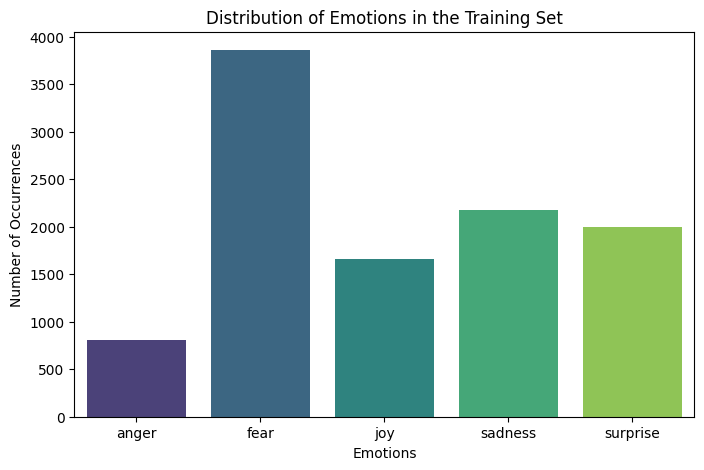

In [7]:
plt.figure(figsize=(8, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribution of Emotions in the Training Set')
plt.ylabel('Number of Occurrences')
plt.xlabel('Emotions')
plt.show()

In [8]:
row_sums = df_train[emotion_cols].sum(axis=1)
no_label_count = (row_sums == 0).sum()
print(f"Texts with no labeled emotion: {no_label_count}")

Texts with no labeled emotion: 676


In [9]:
single_label_count = (row_sums == 1).sum()
print(f"Texts with one labeled emotion: {single_label_count}")

Texts with one labeled emotion: 2743


In [10]:
multi_label_count = (row_sums > 1).sum()
print(f"Texts with multiple labeled emotions: {multi_label_count}")

Texts with multiple labeled emotions: 3408


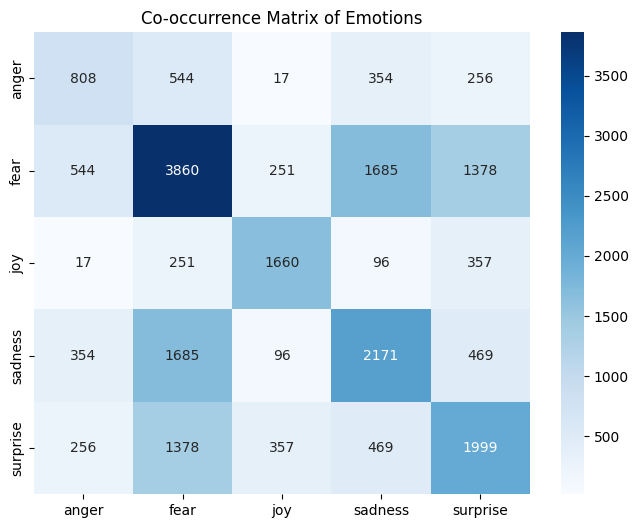

In [11]:
co_occurrence_matrix = df_train[emotion_cols].T.dot(df_train[emotion_cols])
plt.figure(figsize=(8, 6))
sns.heatmap(co_occurrence_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Co-occurrence Matrix of Emotions')
plt.show()

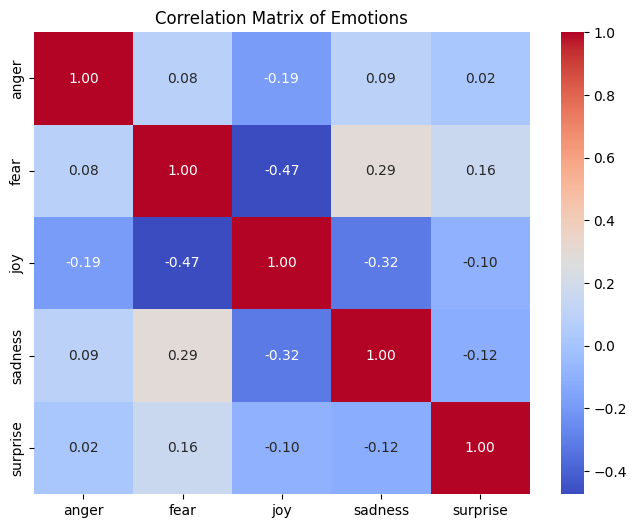

In [12]:
correlation_matrix = df_train[emotion_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Emotions')
plt.show()

In [13]:
df_train['char_count'] = df_train['text'].str.len()
df_train['word_count'] = df_train['text'].str.split().str.len()

df_train['avg_word_len'] = df_train['char_count'] / df_train['word_count']
df_train[['char_count', 'word_count', 'avg_word_len']].describe()

,char_count,word_count,avg_word_len
count,6827.000000,6827.000000,6827.000000
mean,79.430790,15.684781,5.124435
std,57.397397,11.365744,0.731251
min,5.000000,1.000000,3.000000
25%,39.000000,8.000000,4.666667
50%,65.000000,13.000000,5.000000
75%,103.000000,20.000000,5.454545
max,450.000000,89.000000,21.000000


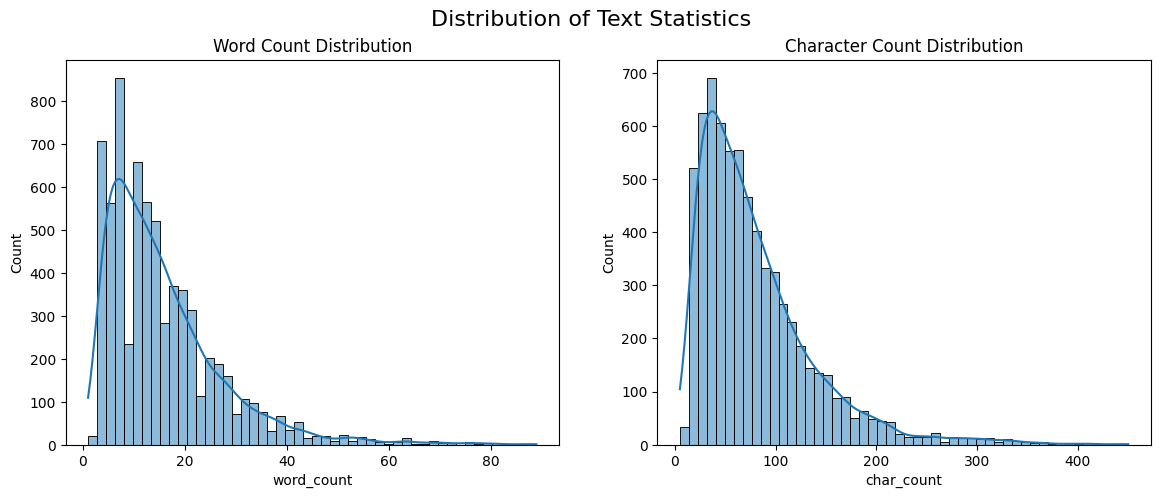

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Text Statistics', fontsize=16)
sns.histplot(ax=axes[0], data=df_train, x='word_count', bins=50, kde=True)
axes[0].set_title('Word Count Distribution')
sns.histplot(ax=axes[1], data=df_train, x='char_count', bins=50, kde=True)
axes[1].set_title('Character Count Distribution')
plt.show()

# MILESTONE 1

In [15]:
label_counts.idxmax(), label_counts.max()

('fear', np.int64(3860))

In [16]:
two_label_count = (row_sums == 2).sum()
print(f"Texts with two labeled emotions: {two_label_count}")

Texts with two labeled emotions: 2587


In [17]:
joy_sad = df_train[(df_train["joy"] == 1) & (df_train["sadness"] == 1)]
print(joy_sad.shape)
joy_sad.head()

(96, 11)


,id,text,anger,fear,joy,sadness,surprise,emotions,char_count,word_count,avg_word_len
110,110,the next day my knees were covered in bruises....,0,0,1,1,1,['joy' 'sadness' 'surprise'],105,20,5.250000
115,115,i begged to come with him to see the house.,0,1,1,1,0,['fear' 'joy' 'sadness'],43,10,4.300000
192,192,"it will not be my dream job, but it will be okay.",0,0,1,1,0,['joy' 'sadness'],49,12,4.083333
357,357,having plucked up the courage to ask her fathe...,0,1,1,1,0,['fear' 'joy' 'sadness'],165,32,5.156250
399,399,its actually a lil funny that i felt like shit...,0,0,1,1,0,['joy' 'sadness'],128,28,4.571429


In [18]:
label_counts["surprise"]/df_train.shape[0] * 100

np.float64(29.280796836091987)

In [19]:
print(f"{label_counts.idxmax()} - {label_counts.idxmin()} = {label_counts.max() - label_counts.min()}")

fear - anger = 3052


In [20]:
ang_fear_cor = df_train["anger"].corr(df_train["fear"])
ang_fear_cor

np.float64(0.07972646850754525)

In [21]:
word_lengths = df_train['text'].str.split().explode().str.len()
median_word_length = word_lengths.median()
print(f"The median word length of all texts is: {median_word_length} characters.")

The median word length of all texts is: 4.0 characters.


In [22]:
word_counts = df_train['text'].str.split().apply(len)
median_word_count = word_counts.median()
print(f"The median number of words per text is: {median_word_count}")

The median number of words per text is: 13.0
